# GeoPandas AI - Flood Analysis Sample

In this Jupyter Notebook, we propose to perform geospatial analysis of a dataset using GeoPandas AI.

# Initialisation of GeoPandas AI

GeoPandas AI relies on an external AI service, which you can configure through LiteLLM.




In [9]:
from litellm import completion
import os

import geopandas as gpd
import geopandasai as gai
from folium import Map
from geopandasai import update_geopandasai_config
from matplotlib.figure import Figure

update_geopandasai_config(
    lite_llm_config=dict(
        model="openai/gemma3n:e4b",
    api_base="http://127.0.0.1:11434/v1",
    api_key="ollama",
    )
)



# Data analysis

We will now load the different data files as gdf, convert them to GeoDataFrameAI, to be able to interact with them in Natural Language.

A temperature of 0 is provided to increase the reproductibility of this notebook. However, this is not enough to guarentee that the LLM will produce 100% deterministic results. Therefore, resetting the cache may lead to different outputs.

In [10]:
# gai.reset_cache()

In [11]:
floodedAreas_gdf = gpd.read_file(
    "./Data/Shps/boiseFlood200yr_v4.shp")  # gai.read_file(...), would also work and directly instantiate a GeoDataFrameAI
highways_gdf = gpd.read_file("./Data/Shps/primaryHighways.gpkg")
facilities_gdf = gpd.read_file('./Data/Shps/schoolsHospitalsPoliceFire.gpkg')

In [12]:
floodedAreas = gai.GeoDataFrameAI(floodedAreas_gdf)
highways = gai.GeoDataFrameAI(highways_gdf, description="This dataset contains information about roads.")
facilities = gai.GeoDataFrameAI(facilities_gdf)

In [13]:
floodedAreas.chat("What are the the bounds of the flooded areas.")

'The bounds of the flooded areas are: minx=minx, miny=miny, maxx=maxx, maxy=maxy'

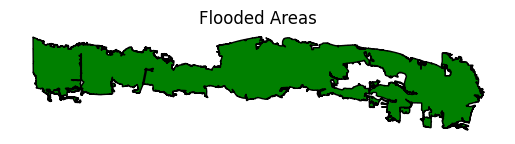

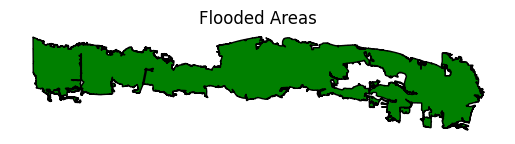

,fid,STAGE,ELEV,USGSID,GRIDID,QCFS,STGRATING,Comments,Area,geometry
0,1.0,14.94,2617.892,13206000,13,23900,"EXTRAPOLATED, from USACE MODEL",0.5-percent chance flow,29243133,"POLYGON ((-116.30349 43.68274, -116.3035 43.68..."


In [14]:
floodedAreas.chat("Plot the flooded areas.")

<Figure size 640x480 with 1 Axes>

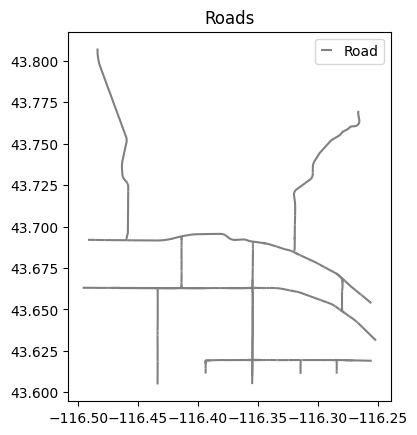

In [15]:
highways.chat("Plot the roads.").improve("Add a legend. Roads with the same name should have the same color.").improve(
    "Improve the legend, it does not fit in its box. Make it scrollable.")

In [16]:
facilities.chat("Find unique amenities.")

['school', 'hospital', 'fire_station']

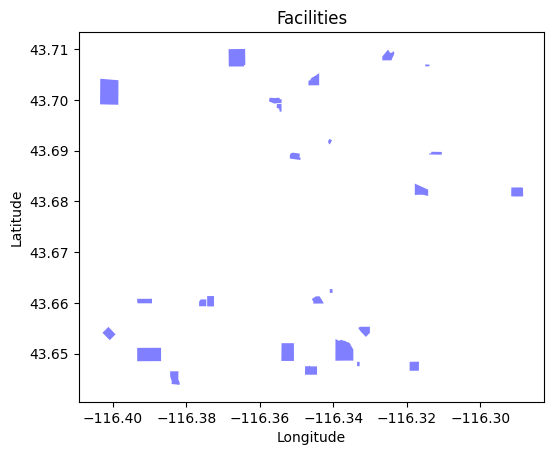

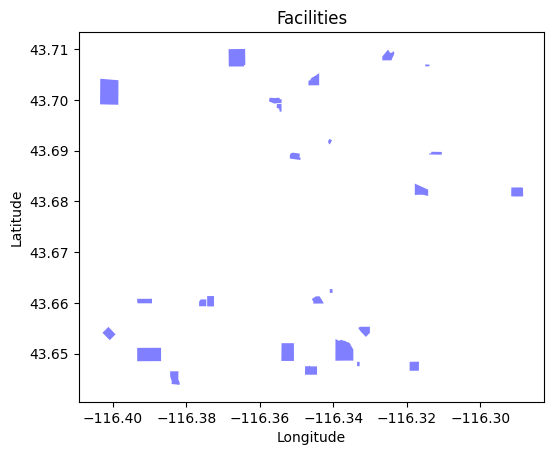

In [17]:
fig = facilities.chat("Plot the facilities.", return_type=Figure)

In [18]:
highways.chat(
    "Plot the highways the schools, and flooded areas.",
    floodedAreas,
    facilities,
    return_type=Map,
).improve("Save in map.html file")

ValueError: No valid code snippet. Here is the last code snippet that was generated:

import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import pandas as pd
from folium.folium import Layer, GeoJson
from folium.features import Circle
def execute(df_1, df_2, df_3) -> folium.folium.Map:
    """
    Plots highways, schooools, and flooded areas on a map.

    Args:
        df_1 (pd.DataFrame): DataFrame containing highway data (e.g., shapefile path).
        df_2 (pd.DataFrame): DataFrame containing school data (e.g., shapefile path).
        df_3 (pd.DataFrame): DataFrame containing flooded area data (e.g., shapefile path).

    Returns:
        folium.folium.Map: A Folium map object with layers for highways, schools, and flooded areas.
    """
    # Create the map object
    m = folium.Map(location=[df_1['geometry'].centroid.y.mean(), df_1['geometry'].centroid.x.mean()], zoom_start=10)
    # Add highway layer
    folium.GeoJson(df_1, name='hightways').add_to(m)
    # Ad

In [19]:
floodedFacilities = facilities.chat(
    "Add a Flooded column to the facilities based on whether they are in the flooded areas",
    floodedAreas,
)


ValueError: No valid code snippet. Here is the last code snippet that was generated:
import geopandas as gpd
import pandas as pd

def execute(df_1: gpd.GeoDataFrame, df_2: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Adds a 'Flooded' column to the facilities based on whether they are in the flooded areas.

    Args:
        df_1 (gpdsai.geo_dataframe_ai.GeoDataFrame): GeoDataFrame containing facility information.
        df_2 (gpdsai.geo_dataframe_ai.GeoDataFrame): GeoDataFrame containing flooded areas.

    Returns:
        pd.DataFrame: The updated facility DataFrame with a 'Flooded' column.
    """
    # Perform a spatial join to find facilities within flooded areas
    joined = gpd.sjoin(df_1, df_2, how="left", using="geometry")

    # Create the 'Flooded' column based on the presence of a match
    joined['Flooded'] = joined['geometry'].notna()

    # Return the updated DataFrame
    return joined

And the last exception that was raised:
sjoin() got an unexpected keyword argumen

It should be noted, that when GeoPandas-AI returns a GDF or a DF, improve functions cannot yet be "chained" on the same line. If the users need to improve the GDF-AI, they need to do it in a separate expression:

In [ ]:
# floodedFacilities = facilities.improve("Keep only the facilities flooded.")

In [20]:
floodedFacilities.chat("Export to the Out/floodedSchools.gpkg. Keep only the facilities flooded.", return_type=None)

NameError: name 'floodedFacilities' is not defined

In [ ]:
facilities.inspect()

In [ ]:
facilities.inject("flooded")

In [ ]:
import ai

ai.flooded(facilities_gdf, floodedAreas_gdf)